# Checkpoint 2 – Parte 2: Regressão Linear e Estabilidade da Rede Elétrica

Construção e comparação de dois modelos de **Regressão Linear** para prever o valor numérico da coluna `stab`.

## Identificação do grupo

| Nome completo | RM |
|---|---|
| _preencher_ | _preencher_ |
| _preencher_ | _preencher_ |
| _preencher_ | _preencher_ |

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')

## 2. Carregamento e análise inicial do dataset

In [2]:
# Lê o CSV da pasta dados/ do repositório; no Colab (sem a pasta), baixa do GitHub do grupo
import os
caminho_local = '../dados/Data_for_UCI_named.csv'
url = 'https://raw.githubusercontent.com/denizeferrante/MachineLearning_DadosEnergia/refs/heads/main/dados/Data_for_UCI_named.csv'
df = pd.read_csv(caminho_local if os.path.exists(caminho_local) else url)
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [3]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 10000
Quantidade de colunas: 14


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB


In [5]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())

Valores ausentes por coluna:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64


In [6]:
df.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


### Registro da análise inicial

**Quantidade de linhas:** 10.000
**Quantidade de colunas:** 14
**Existem valores ausentes?** Não — todas as colunas têm 10.000 valores não nulos.
**Observações importantes sobre o dataset:** são 13 colunas numéricas (`float64`) e 1 categórica (`stabf`).
As variáveis `tau1–tau4` (tempo de reação, 0,5 a 10), `p1–p4` (potência) e `g1–g4` (coeficiente de elasticidade de preço, 0,05 a 1)
estão em escalas diferentes. A coluna `stab` é o target numérico (valores negativos = rede estável) e `stabf` é sua versão categórica,
portanto `stabf` não deve ser usada como variável de entrada.

## 3. Definição da variável target

In [7]:
y = df['stab']
y.head()

0    0.055347
1   -0.005957
2    0.003471
3    0.028871
4    0.049860
Name: stab, dtype: float64

## 4. Matriz de correlação

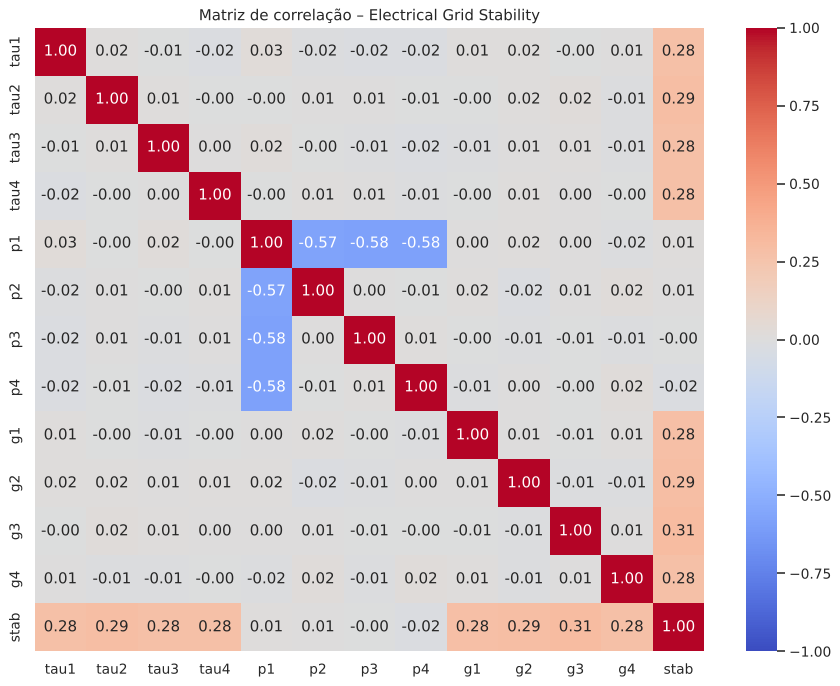

In [8]:
correlacao = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de correlação – Electrical Grid Stability')
plt.show()

## 5. Seleção das cinco variáveis e gráficos de dispersão (com apoio do Gemini)

In [9]:
# (1) e (2) correlação com stab, sem a própria stab
corr_stab = correlacao['stab'].drop('stab')

# (3) ordena pelo valor ABSOLUTO e pega as 5 maiores
cinco_variaveis = corr_stab.abs().sort_values(ascending=False).head(5).index.tolist()

# (4) mostra os valores originais, preservando o sinal
print('Cinco variáveis com maior correlação absoluta com stab:')
for i, col in enumerate(cinco_variaveis, start=1):
    print(f'{i}. {col}: {corr_stab[col]:+.4f}')

Cinco variáveis com maior correlação absoluta com stab:
1. g3: +0.3082
2. g2: +0.2936
3. tau2: +0.2910
4. g1: +0.2828
5. tau3: +0.2807


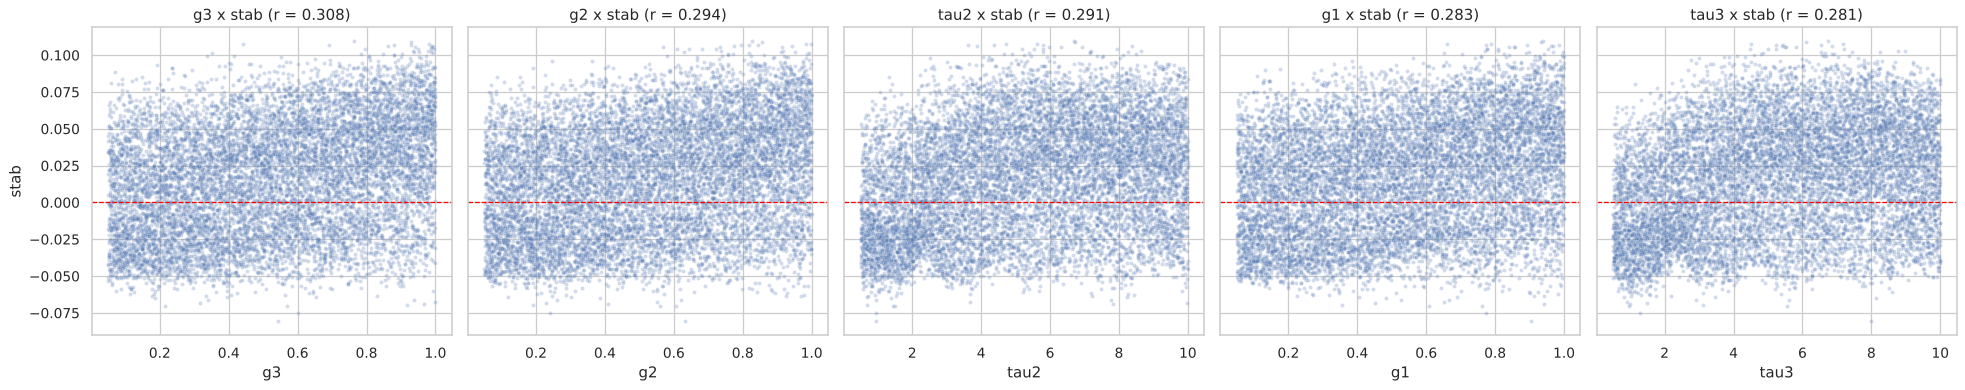

In [10]:
# (6) um gráfico de dispersão para cada variável
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)
for ax, col in zip(axes, cinco_variaveis):
    sns.scatterplot(data=df, x=col, y='stab', ax=ax, alpha=0.25, s=10)
    ax.set_title(f'{col} x stab (r = {corr_stab[col]:.3f})')
    ax.axhline(0, color='red', lw=1, ls='--')
plt.tight_layout()
plt.show()

### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | g3 | +0,3082 |
| 2 | g2 | +0,2936 |
| 3 | tau2 | +0,2910 |
| 4 | g1 | +0,2828 |
| 5 | tau3 | +0,2807 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**
Resposta: **`g3`**, com correlação de +0,3082.

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**
Resposta: todas as cinco correlações são **positivas e fracas** (entre 0,28 e 0,31). Os pontos formam nuvens largas,
com uma leve tendência de subida: quando `g` ou `tau` aumentam, `stab` tende a ficar mais positiva (rede mais instável),
mas com muita dispersão. Nenhuma variável sozinha explica bem `stab`. Também se nota que as variáveis `p1–p4` têm correlação
praticamente nula, e que `tau1`, `tau4` e `g4` têm correlações muito próximas das selecionadas (≈ 0,28) — ficaram de fora por pouco.

# Modelo 1 – Cinco maiores correlações

In [11]:
X = df[cinco_variaveis]
display(X.head())
display(y.head())

,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


0    0.055347
1   -0.005957
2    0.003471
3    0.028871
4    0.049860
Name: stab, dtype: float64

[None]

## 6. Separação entre treino e teste

In [12]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Treino: {X_treino.shape[0]} registros')
print(f'Teste : {X_teste.shape[0]} registros')

Treino: 8000 registros
Teste : 2000 registros


## 7. Treinamento e previsões do Modelo 1

In [13]:
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)

y_previsao_1 = modeloLR.predict(X_teste)
print('Primeiras previsões:', y_previsao_1[:5].round(4))

Primeiras previsões: [ 0.0479  0.0378 -0.0014 -0.0342  0.0123]


## 8. Métricas do Modelo 1

In [14]:
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print(f'Modelo 1 - R² : {r2_modelo_1:.4f}')
print(f'Modelo 1 - MAE: {mae_modelo_1:.6f}')
print(f'Modelo 1 - MSE: {mse_modelo_1:.6f}')

Modelo 1 - R² : 0.4018
Modelo 1 - MAE: 0.023310
Modelo 1 - MSE: 0.000811


# Modelo 2 – Variáveis `tau` e `g`

In [15]:
colunas_tau_g = [col for col in df.columns if col.startswith('tau') or col.startswith('g')]
X_tau_g = df[colunas_tau_g]
print('Colunas selecionadas:', colunas_tau_g)
X_tau_g.head()

Colunas selecionadas: ['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']


,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## 9. Separação entre treino e teste do Modelo 2

In [16]:
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)
print(f'Treino: {X2_treino.shape[0]} registros')
print(f'Teste : {X2_teste.shape[0]} registros')

# Confirma que os dois modelos são avaliados nos mesmos registros de teste
print('y_teste e y2_teste têm os mesmos índices?', y_teste.index.equals(y2_teste.index))

Treino: 8000 registros
Teste : 2000 registros
y_teste e y2_teste têm os mesmos índices? True


## 10. Treinamento, previsões e métricas do Modelo 2

In [17]:
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)

y_previsao_2 = modeloLR_tau_g.predict(X2_teste)

r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print(f'Modelo 2 - R² : {r2_modelo_2:.4f}')
print(f'Modelo 2 - MAE: {mae_modelo_2:.6f}')
print(f'Modelo 2 - MSE: {mse_modelo_2:.6f}')

Modelo 2 - R² : 0.6452
Modelo 2 - MAE: 0.017553
Modelo 2 - MSE: 0.000481


# Comparação das métricas dos dois modelos

In [18]:
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'Variáveis utilizadas': [', '.join(cinco_variaveis), ', '.join(colunas_tau_g)],
    'R²':  [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2],
})
comparacao_modelos

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,"g3, g2, tau2, g1, tau3",0.401770,0.023310,0.000811
1,Modelo 2,"tau1, tau2, tau3, tau4, g1, g2, g3, g4",0.645229,0.017553,0.000481


## Visualização comparativa

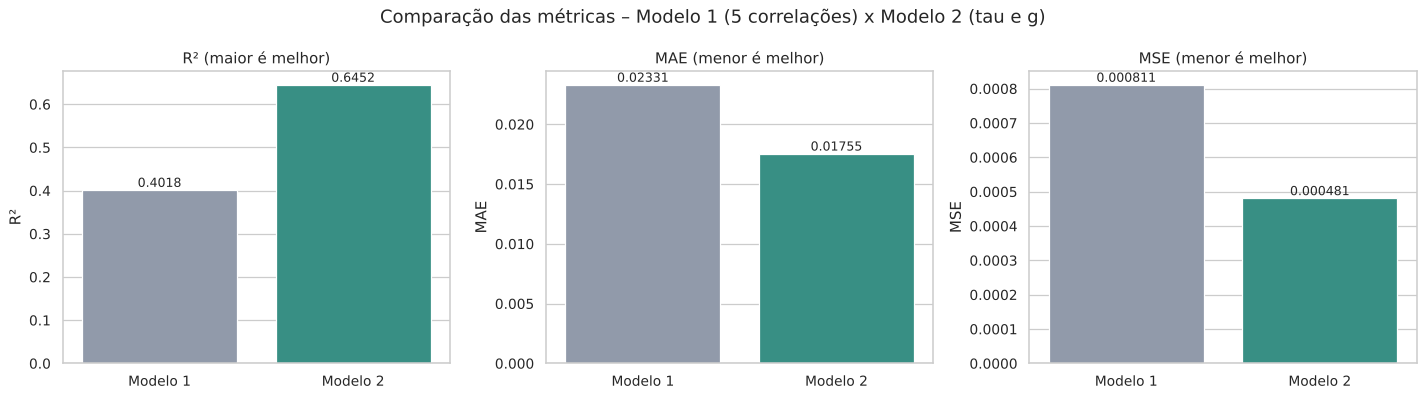

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metricas = [('R²', 'maior é melhor', '.4f'), ('MAE', 'menor é melhor', '.5f'), ('MSE', 'menor é melhor', '.6f')]
for ax, (m, legenda, fmt) in zip(axes, metricas):
    sns.barplot(data=comparacao_modelos, x='Modelo', y=m, hue='Modelo',
                palette=['#8d99ae', '#2a9d8f'], legend=False, ax=ax)
    ax.set_title(f'{m} ({legenda})')
    ax.set_xlabel('')
    for barra in ax.patches:
        ax.annotate(format(barra.get_height(), fmt),
                    (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    ha='center', va='bottom', fontsize=10)
plt.suptitle('Comparação das métricas – Modelo 1 (5 correlações) x Modelo 2 (tau e g)')
plt.tight_layout()
plt.show()

## Análise comparativa final

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**
Resposta: o **Modelo 2**, com R² = **0,6452**, contra **0,4018** do Modelo 1. O Modelo 2 explica cerca de 64,5% da variação de `stab`; o Modelo 1, cerca de 40,2%.

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**
Resposta: o **Modelo 2**, com MAE = **0,01755**, contra **0,02331** do Modelo 1 — um erro absoluto médio cerca de 25% menor.

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**
Resposta: o **Modelo 2**, com MSE = **0,000481**, contra **0,000811** do Modelo 1 — cerca de 41% menor, indicando que o Modelo 2 também comete menos erros grandes.

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**
Resposta: sim. O Modelo 2 tem o **maior R²** (0,6452 > 0,4018), o **menor MAE** (0,01755 < 0,02331) e o **menor MSE** (0,000481 < 0,000811). As três métricas são coerentes: ele explica mais a variação de `stab` e erra menos, tanto em média quanto nos erros maiores.

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**
Resposta: o desempenho melhorou bastante. Ao incluir `tau1`, `tau4` e `g4`, que ficaram de fora do Modelo 1 por diferença mínima de correlação (≈ 0,28),
o R² subiu cerca de 24 pontos percentuais. Isso mostra que selecionar variáveis só pela correlação individual com o target pode descartar informação útil:
como todas as variáveis `tau` e `g` têm correlações parecidas e são independentes entre si, cada uma contribui com informação diferente,
e o modelo com o conjunto completo consegue explicar muito mais de `stab`.

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**
Resposta: o **Modelo 2 (`modeloLR_tau_g`)**, pois apresenta melhor resultado nas três métricas: R² de 0,6452 (vs 0,4018), MAE de 0,01755 (vs 0,02331)
e MSE de 0,000481 (vs 0,000811). Ainda assim, cerca de 35% da variação de `stab` continua sem explicação, o que sugere que a relação não é totalmente linear
e que modelos não lineares poderiam melhorar ainda mais as previsões.